# Lab 3: Attention-based NMT

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

## 1. Load Data từ Lab 1

**Giải thích**: Chúng ta cần tái sử dụng Vocab class và dữ liệu từ Lab 1 để có từ điển và corpus tiếng Anh-Việt.

In [2]:
# Định nghĩa tokenize function
def tokenize(sentence):
    return sentence.lower().split()

# Định nghĩa Vocab class từ Lab 1
class Vocab:
    PAD_TOKEN = '<PAD>'
    BOS_TOKEN = '<BOS>'
    EOS_TOKEN = '<EOS>'
    
    def __init__(self):
        self.word2id = {}
        self.id2word = {}
        self._add_special_tokens()
    
    def _add_special_tokens(self):
        self.word2id[self.PAD_TOKEN] = 0
        self.id2word[0] = self.PAD_TOKEN
        self.word2id[self.BOS_TOKEN] = 1
        self.id2word[1] = self.BOS_TOKEN
        self.word2id[self.EOS_TOKEN] = 2
        self.id2word[2] = self.EOS_TOKEN

    def add_word(self, w):
        if w not in self.word2id:
            idx = len(self.word2id)
            self.word2id[w] = idx
            self.id2word[idx] = w
    
    def build_vocab(self, sentences):
        for sentence in sentences:
            words = tokenize(sentence)
            for word in words:
                self.add_word(word)
    
    def encode(self, sentence, add_special_tokens=True):
        words = tokenize(sentence)
        ids = [self.word2id[word] for word in words if word in self.word2id]
        if add_special_tokens:
            ids = [self.word2id[self.BOS_TOKEN]] + ids + [self.word2id[self.EOS_TOKEN]]
        return ids
    
    def decode(self, ids, skip_special_tokens=True):
        words = []
        for id in ids:
            if id in self.id2word:
                word = self.id2word[id]
                if skip_special_tokens and word in [self.PAD_TOKEN, self.BOS_TOKEN, self.EOS_TOKEN]:
                    continue
                words.append(word)
        return ' '.join(words)
    
    def __len__(self):
        return len(self.word2id)

# Load data
with open('../NLP LAB 1_ Preprocessing/data/train.en', 'r', encoding='utf-8') as f:
    en_sentences = [line.strip() for line in f.readlines()]

with open('../NLP LAB 1_ Preprocessing/data/train.vi', 'r', encoding='utf-8') as f:
    vi_sentences = [line.strip() for line in f.readlines()]

# Build vocabularies
en_vocab = Vocab()
en_vocab.build_vocab(en_sentences)
vi_vocab = Vocab()
vi_vocab.build_vocab(vi_sentences)

print(f"English vocab size: {len(en_vocab)}")
print(f"Vietnamese vocab size: {len(vi_vocab)}")
print(f"Number of parallel sentences: {len(en_sentences)}")

English vocab size: 34
Vietnamese vocab size: 43
Number of parallel sentences: 10


## 2. Định nghĩa Encoder

**Giải thích**: Encoder chuyển câu nguồn thành hidden states. Chúng ta cần outputs của tất cả timesteps để tính attention.

In [3]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
    
    def forward(self, src):
        # src: [batch_size, src_len]
        embedded = self.embedding(src)  # [batch_size, src_len, emb_dim]
        outputs, hidden = self.gru(embedded)  # outputs: [batch_size, src_len, hidden_dim]
        return outputs, hidden

# Test Encoder
encoder = Encoder(input_dim=len(en_vocab), emb_dim=32, hidden_dim=64)
# Encode first sentence
src_ids = torch.tensor([en_vocab.encode(en_sentences[0])])
enc_outputs, enc_hidden = encoder(src_ids)
print(f"Encoder outputs shape: {enc_outputs.shape}")  # [1, src_len, 64]
print(f"Encoder hidden shape: {enc_hidden.shape}")    # [1, 1, 64]

Encoder outputs shape: torch.Size([1, 6, 64])
Encoder hidden shape: torch.Size([1, 1, 64])


## 3. Định nghĩa Dot-Product Attention

**Giải thích**: Attention mechanism tính toán mức độ liên quan giữa decoder state (query) và tất cả encoder outputs (keys). Sử dụng dot-product attention với softmax để tạo attention weights.

In [4]:
class DotAttention(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, query, keys):
        """
        query: [batch_size, hidden_dim] - decoder hidden state
        keys: [batch_size, src_len, hidden_dim] - encoder outputs
        
        Returns:
        context: [batch_size, hidden_dim] - weighted sum of encoder outputs
        attention_weights: [batch_size, src_len] - attention distribution
        """
        # Compute attention scores: query · keys^T
        # query.unsqueeze(1): [batch_size, 1, hidden_dim]
        # keys: [batch_size, src_len, hidden_dim]
        scores = torch.bmm(query.unsqueeze(1), keys.transpose(1, 2))  # [batch_size, 1, src_len]
        scores = scores.squeeze(1)  # [batch_size, src_len]
        
        # Apply softmax to get attention weights
        attention_weights = F.softmax(scores, dim=1)  # [batch_size, src_len]
        
        # Compute context vector: weighted sum of encoder outputs
        # attention_weights.unsqueeze(1): [batch_size, 1, src_len]
        # keys: [batch_size, src_len, hidden_dim]
        context = torch.bmm(attention_weights.unsqueeze(1), keys)  # [batch_size, 1, hidden_dim]
        context = context.squeeze(1)  # [batch_size, hidden_dim]
        
        return context, attention_weights

# Test DotAttention
attention = DotAttention()
# Giả sử decoder hidden: [1, 64], encoder outputs: [1, 7, 64]
query = enc_hidden.squeeze(0)  # [1, 64]
keys = enc_outputs  # [1, src_len, 64]
context, attn_weights = attention(query, keys)
print(f"Context shape: {context.shape}")  # [1, 64]
print(f"Attention weights shape: {attn_weights.shape}")  # [1, src_len]
print(f"Attention weights sum: {attn_weights.sum()}")  # Should be 1.0

Context shape: torch.Size([1, 64])
Attention weights shape: torch.Size([1, 6])
Attention weights sum: 1.0


## 4. Định nghĩa Attentive Decoder

**Giải thích**: Decoder nhận encoder outputs và sử dụng attention để tạo context vector. Context vector được concat với decoder output trước khi project ra vocabulary.

In [5]:
class AttentiveDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.attention = DotAttention()
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        # Output projection: concat(gru_output, context) -> vocab
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)
    
    def forward(self, input, hidden, encoder_outputs):
        """
        input: [batch_size] - current target token
        hidden: [1, batch_size, hidden_dim] - previous decoder hidden state
        encoder_outputs: [batch_size, src_len, hidden_dim]
        
        Returns:
        output: [batch_size, output_dim] - vocabulary distribution
        hidden: [1, batch_size, hidden_dim] - new hidden state
        attention_weights: [batch_size, src_len] - attention distribution
        """
        # Embedding
        input = input.unsqueeze(1)  # [batch_size, 1]
        embedded = self.embedding(input)  # [batch_size, 1, emb_dim]
        
        # GRU step
        gru_output, hidden = self.gru(embedded, hidden)  # gru_output: [batch_size, 1, hidden_dim]
        gru_output = gru_output.squeeze(1)  # [batch_size, hidden_dim]
        
        # Compute attention
        query = gru_output  # [batch_size, hidden_dim]
        context, attention_weights = self.attention(query, encoder_outputs)
        
        # Concatenate gru_output and context, then project to vocabulary
        combined = torch.cat([gru_output, context], dim=1)  # [batch_size, hidden_dim*2]
        output = self.fc_out(combined)  # [batch_size, output_dim]
        
        return output, hidden, attention_weights

# Test AttentiveDecoder
decoder = AttentiveDecoder(output_dim=len(vi_vocab), emb_dim=32, hidden_dim=64)
# Test with first target token (BOS)
trg_input = torch.tensor([vi_vocab.word2id[vi_vocab.BOS_TOKEN]])  # [1]
dec_hidden = enc_hidden  # [1, 1, 64]
dec_output, dec_hidden, attn_weights = decoder(trg_input, dec_hidden, enc_outputs)
print(f"Decoder output shape: {dec_output.shape}")  # [1, vocab_size]
print(f"Decoder hidden shape: {dec_hidden.shape}")  # [1, 1, 64]
print(f"Attention weights shape: {attn_weights.shape}")  # [1, src_len]

Decoder output shape: torch.Size([1, 43])
Decoder hidden shape: torch.Size([1, 1, 64])
Attention weights shape: torch.Size([1, 6])


## 5. Định nghĩa Attentive Seq2Seq Model

**Giải thích**: Model kết hợp Encoder và AttentiveDecoder. Forward pass hỗ trợ teacher forcing và lưu attention weights để visualization.

In [6]:
class AttentiveSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        """
        src: [batch_size, src_len]
        trg: [batch_size, trg_len]
        
        Returns:
        outputs: [batch_size, trg_len, vocab_size]
        attention_weights_list: list of [batch_size, src_len]
        """
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features
        
        # Encode
        encoder_outputs, hidden = self.encoder(src)
        
        # Initialize outputs and attention weights storage
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size)
        attention_weights_list = []
        
        # First input is BOS token
        input = trg[:, 0]
        
        for t in range(1, trg_len):
            output, hidden, attention_weights = self.decoder(input, hidden, encoder_outputs)
            outputs[:, t] = output
            attention_weights_list.append(attention_weights)
            
            # Teacher forcing
            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = trg[:, t] if teacher_force else top1
        
        return outputs, attention_weights_list
    
    def greedy_decode(self, src, max_len=20):
        """
        Greedy decoding with attention weights recording
        """
        self.eval()
        with torch.no_grad():
            encoder_outputs, hidden = self.encoder(src)
            
            input = torch.tensor([vi_vocab.word2id[vi_vocab.BOS_TOKEN]])
            decoded_ids = []
            attention_weights_list = []
            
            for _ in range(max_len):
                output, hidden, attention_weights = self.decoder(input, hidden, encoder_outputs)
                attention_weights_list.append(attention_weights.squeeze(0).cpu().numpy())
                
                top1 = output.argmax(1)
                decoded_ids.append(top1.item())
                
                if top1.item() == vi_vocab.word2id[vi_vocab.EOS_TOKEN]:
                    break
                
                input = top1
        
        return decoded_ids, attention_weights_list

# Initialize model
model = AttentiveSeq2Seq(encoder, decoder)
print("Model initialized successfully!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Model initialized successfully!
Total parameters: 45643


## 6. Training Loop

**Giải thích**: Train model với cross-entropy loss trên tất cả các câu trong corpus. Sử dụng teacher forcing ratio = 0.5.

Epoch 20/200, Loss: 0.7318
Epoch 40/200, Loss: 0.1092
Epoch 60/200, Loss: 0.0379
Epoch 80/200, Loss: 0.0199
Epoch 100/200, Loss: 0.0124
Epoch 120/200, Loss: 0.0086
Epoch 140/200, Loss: 0.0063
Epoch 160/200, Loss: 0.0048
Epoch 180/200, Loss: 0.0037
Epoch 200/200, Loss: 0.0030
Training completed!


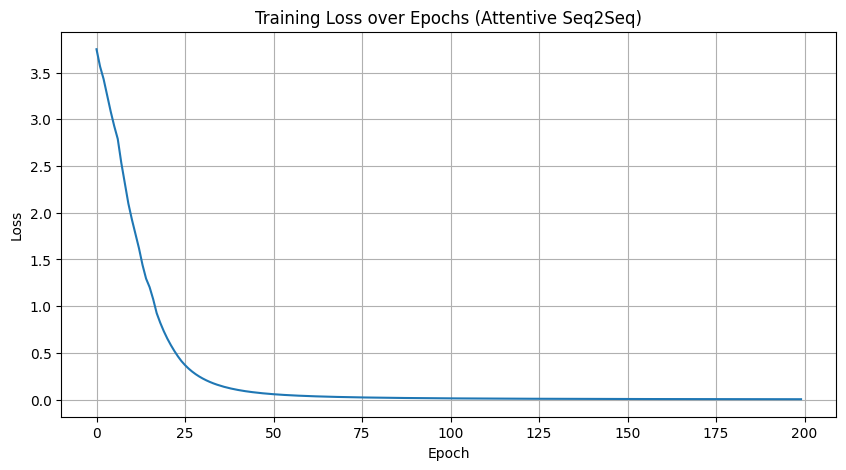

In [7]:
# Prepare training data
def prepare_batch(en_sent, vi_sent):
    src = torch.tensor([en_vocab.encode(en_sent)])
    trg = torch.tensor([vi_vocab.encode(vi_sent)])
    return src, trg

# Training setup
criterion = nn.CrossEntropyLoss(ignore_index=vi_vocab.word2id[vi_vocab.PAD_TOKEN])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
n_epochs = 200
losses = []

model.train()
for epoch in range(n_epochs):
    epoch_loss = 0
    
    for en_sent, vi_sent in zip(en_sentences, vi_sentences):
        src, trg = prepare_batch(en_sent, vi_sent)
        
        optimizer.zero_grad()
        
        # Forward pass
        output, _ = model(src, trg, teacher_forcing_ratio=0.5)
        
        # Reshape for loss calculation
        output = output[:, 1:].reshape(-1, output.shape[-1])  # Skip BOS
        trg = trg[:, 1:].reshape(-1)  # Skip BOS
        
        # Calculate loss
        loss = criterion(output, trg)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(en_sentences)
    losses.append(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}")

print("Training completed!")

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs (Attentive Seq2Seq)')
plt.grid(True)
plt.show()

## 7. Evaluation và Translation Examples

**Giải thích**: Test model trên các câu training để xem quality của translations.

In [8]:
# Test translations
print("="*60)
print("Translation Examples:")
print("="*60)

for i in range(min(5, len(en_sentences))):
    src_sent = en_sentences[i]
    trg_sent = vi_sentences[i]
    
    # Encode source
    src_ids = torch.tensor([en_vocab.encode(src_sent)])
    
    # Decode
    decoded_ids, attention_weights = model.greedy_decode(src_ids, max_len=20)
    
    # Convert to text
    predicted = vi_vocab.decode(decoded_ids, skip_special_tokens=True)
    
    print(f"\nExample {i+1}:")
    print(f"  Source (EN): {src_sent}")
    print(f"  Target (VI): {trg_sent}")
    print(f"  Predicted:   {predicted}")

print("\n" + "="*60)

Translation Examples:

Example 1:
  Source (EN): i am a student
  Target (VI): tôi là sinh viên
  Predicted:   tôi là sinh viên

Example 2:
  Source (EN): i am a teacher
  Target (VI): tôi là giáo viên
  Predicted:   tôi là giáo viên

Example 3:
  Source (EN): he likes football
  Target (VI): anh ấy thích bóng đá
  Predicted:   anh ấy thích bóng đá

Example 4:
  Source (EN): she likes music
  Target (VI): cô ấy thích âm nhạc
  Predicted:   cô ấy thích âm nhạc

Example 5:
  Source (EN): this is a book
  Target (VI): đây là một cuốn sách
  Predicted:   đây là một cuốn sách



## 8. Visualize Attention Heatmap

**Giải thích**: Attention heatmap cho thấy decoder đang "chú ý" (attend) đến từ nào trong source sentence khi generate mỗi từ trong target sentence. Đây là một trong những yêu cầu chính của lab này.

Generating attention heatmaps...

Example 1:
  Source: i am a student
  Target: tôi là sinh viên
  Predicted: tôi là sinh viên



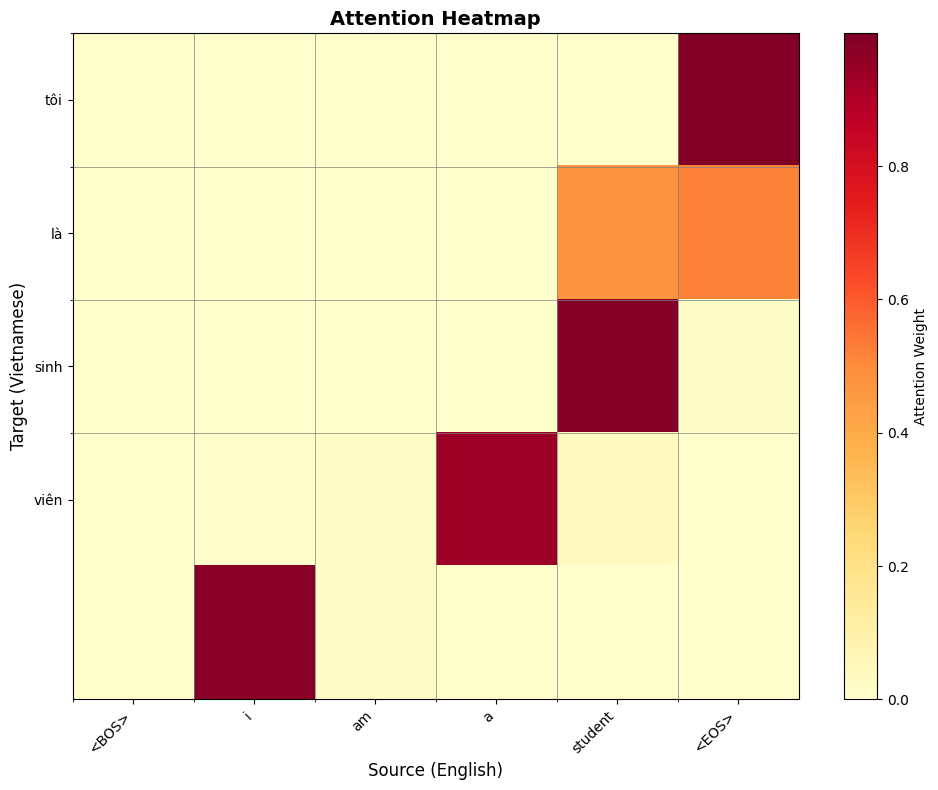

------------------------------------------------------------
Example 2:
  Source: i am a teacher
  Target: tôi là giáo viên
  Predicted: tôi là giáo viên



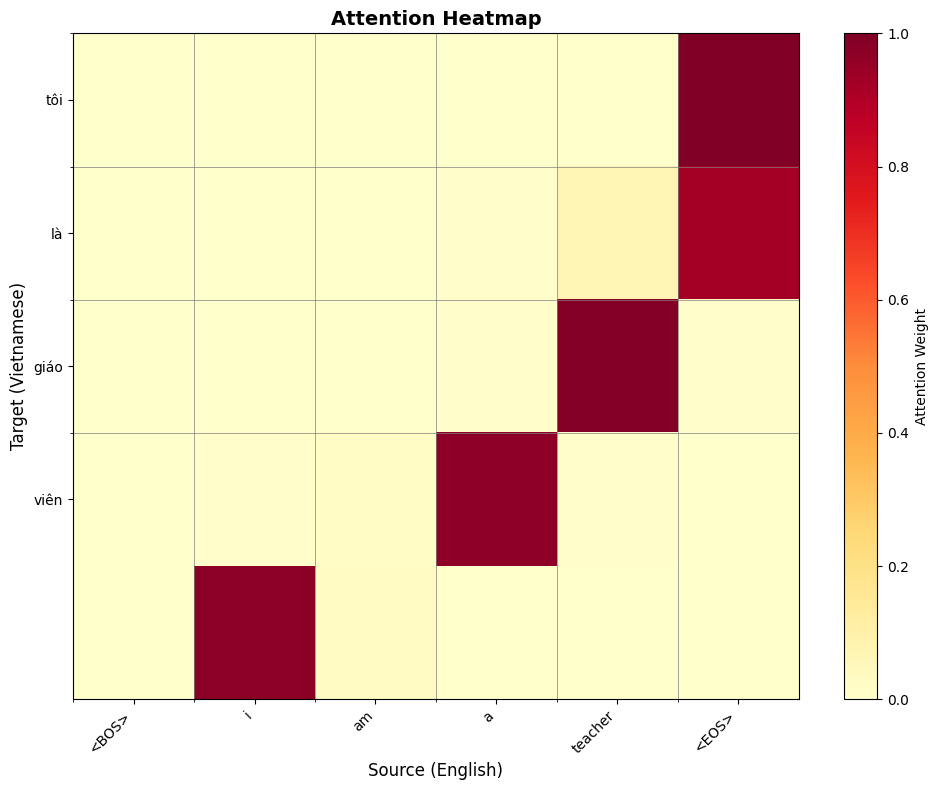

------------------------------------------------------------
Example 3:
  Source: he likes football
  Target: anh ấy thích bóng đá
  Predicted: anh ấy thích bóng đá



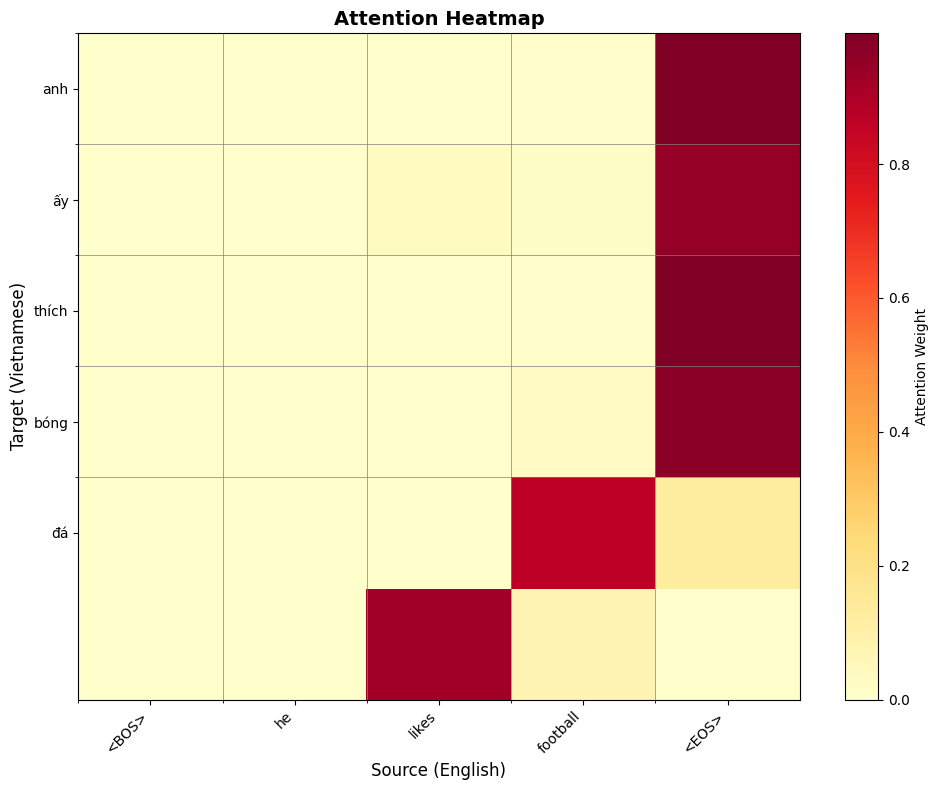

------------------------------------------------------------


In [9]:
def visualize_attention(src_sentence, trg_sentence, attention_weights):
    """
    Visualize attention weights as a heatmap
    
    src_sentence: source sentence (string)
    trg_sentence: target sentence (string) 
    attention_weights: list of attention weight arrays, each [src_len]
    """
    src_tokens = ['<BOS>'] + tokenize(src_sentence) + ['<EOS>']
    trg_tokens = tokenize(trg_sentence)  # Predicted tokens (no special tokens)
    
    # Convert attention_weights to numpy array
    attention_matrix = np.array(attention_weights)  # [trg_len, src_len]
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    
    im = ax.imshow(attention_matrix, cmap='YlOrRd', aspect='auto')
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(src_tokens)))
    ax.set_yticks(np.arange(len(trg_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha='right')
    ax.set_yticklabels(trg_tokens)
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label='Attention Weight')
    
    # Add title and labels
    ax.set_title('Attention Heatmap', fontsize=14, fontweight='bold')
    ax.set_xlabel('Source (English)', fontsize=12)
    ax.set_ylabel('Target (Vietnamese)', fontsize=12)
    
    # Add grid
    ax.set_xticks(np.arange(len(src_tokens))-.5, minor=True)
    ax.set_yticks(np.arange(len(trg_tokens))-.5, minor=True)
    ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()

# Visualize attention for a few examples
print("Generating attention heatmaps...")
print()

for i in range(min(3, len(en_sentences))):
    src_sent = en_sentences[i]
    trg_sent = vi_sentences[i]
    
    # Encode and decode
    src_ids = torch.tensor([en_vocab.encode(src_sent)])
    decoded_ids, attention_weights = model.greedy_decode(src_ids, max_len=20)
    predicted = vi_vocab.decode(decoded_ids, skip_special_tokens=True)
    
    print(f"Example {i+1}:")
    print(f"  Source: {src_sent}")
    print(f"  Target: {trg_sent}")
    print(f"  Predicted: {predicted}")
    print()
    
    # Visualize attention
    visualize_attention(src_sent, predicted, attention_weights)
    print("-" * 60)

## 9. Summary

**Kết quả hoàn thành Lab 3:**
- ✅ Implement dot-product attention mechanism
- ✅ Modified decoder to use attention context vector
- ✅ Trained attentive Seq2Seq model with teacher forcing
- ✅ Visualized attention heatmap showing alignment between source and target words

**Key Insights:**
- Attention mechanism allows the decoder to dynamically focus on relevant parts of the source sentence
- Attention weights show which source words the model attends to when generating each target word
- The heatmap visualization reveals learned alignment patterns between English and Vietnamese